In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Fijar semillas para reproducibilidad
#torch.manual_seed(42)

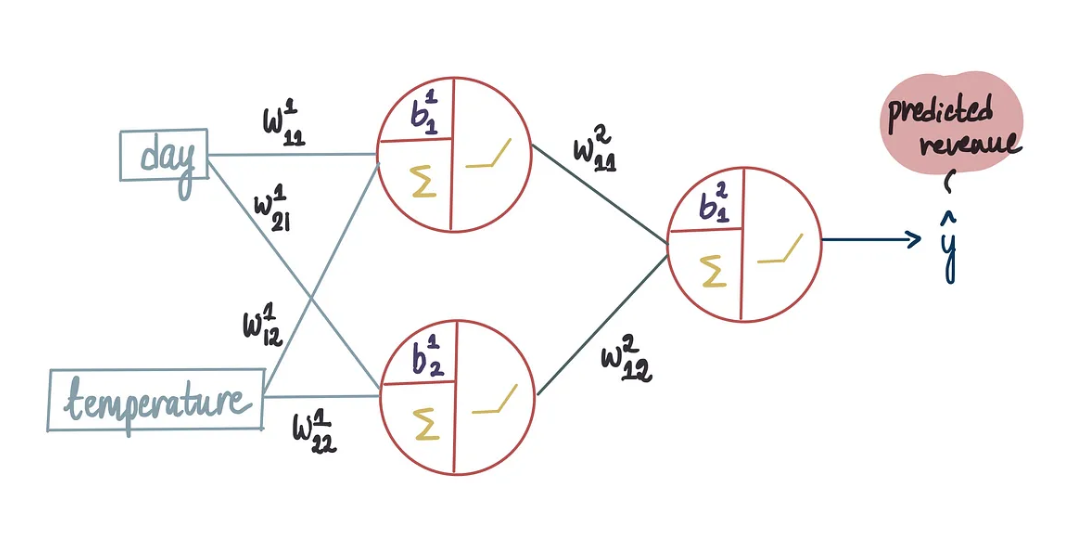

In [4]:
# Data 
day = [2, 6, 1, 3, 2, 5, 7, 4, 3, 1]
temperature = [22, 33, 20, 25, 24, 30, 35, 28, 26, 21]
revenue = [1.51, 2.22, 1.37, 1.77, 1.64, 2.04, 2.42, 1.90, 1.75, 1.45]

In [5]:
# Convert to numpy array
X = np.array(list(zip(day, temperature)), dtype=np.float32)
y = np.array(revenue, dtype=np.float32)

In [6]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
X_scaled

array([[-0.7144345 , -0.9166667 ],
       [ 1.3268069 ,  1.375     ],
       [-1.2247449 , -1.3333334 ],
       [-0.20412415, -0.29166666],
       [-0.7144345 , -0.5       ],
       [ 0.8164966 ,  0.75      ],
       [ 1.8371173 ,  1.7916667 ],
       [ 0.30618623,  0.33333334],
       [-0.20412415, -0.08333334],
       [-1.2247449 , -1.125     ]], dtype=float32)

In [8]:
# Convert data to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [9]:
X_tensor

tensor([[-0.7144, -0.9167],
        [ 1.3268,  1.3750],
        [-1.2247, -1.3333],
        [-0.2041, -0.2917],
        [-0.7144, -0.5000],
        [ 0.8165,  0.7500],
        [ 1.8371,  1.7917],
        [ 0.3062,  0.3333],
        [-0.2041, -0.0833],
        [-1.2247, -1.1250]])

In [11]:
# Build the neural network
class IceCreamSalesModel(nn.Module):
    def __init__(self):
        super(IceCreamSalesModel, self).__init__()
        self.hidden = nn.Linear(2, 2) # La capa interna tiene 2 entradas y 2 salidas.
        self.output = nn.Linear(2, 1) # La capa de salida tiene 2 entradas y 1 salida.
        self.relu = nn.ReLU() # Función de activación ReLU

    def forward(self, x):
        x = self.relu(self.hidden(x))
        x = self.output(x)
        return x

model = IceCreamSalesModel()


In [12]:
# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Train the model
num_epochs = 30000
losses = []

for epoch in range(num_epochs):
    # Forward pass
    predictions = model(X_tensor)
    loss = criterion(predictions, y_tensor)
    losses.append(loss.item())
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

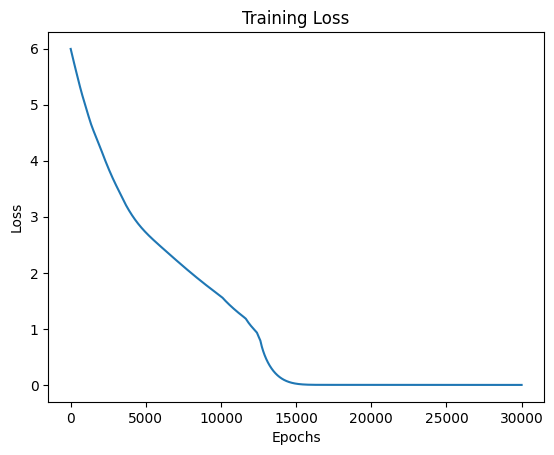

In [14]:
# Plot training loss
plt.plot(losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [15]:
# Make predictions
with torch.no_grad():
    predictions = model(X_tensor)
print("Predicted Revenue:", predictions.numpy())

Predicted Revenue: [[1.526732 ]
 [2.247713 ]
 [1.3845656]
 [1.7196702]
 [1.6282756]
 [2.054775 ]
 [2.3898797]
 [1.9126085]
 [1.7704421]
 [1.4353374]]


In [16]:
# Evaluate the model
mse_value = criterion(predictions, y_tensor).item()
print("Mean Squared Error:", mse_value)

Mean Squared Error: 0.0005848064902238548


In [17]:
# Get weights and biases from the model
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.data.numpy()}")

hidden.weight: [[-0.28207377  0.39940828]
 [ 0.05746185  0.17591792]]
hidden.bias: [-0.19947223  0.84678674]
output.weight: [[-0.45869    1.3853333]]
output.bias: [0.63391805]
